In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
#Check rapide
df.shape, df.isnull().sum()

((200, 5),
 CustomerID                0
 Genre                     0
 Age                       0
 Annual Income (k$)        0
 Spending Score (1-100)    0
 dtype: int64)

In [4]:
#Sélection des features (version simple):K-means sur les 2 variables les plus classiques :
X = df[["Annual Income (k$)", "Spending Score (1-100)"]].copy()
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [5]:
#Standardisation (important pour K-means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

C:\Users\roseb\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\roseb\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\roseb\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\roseb\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

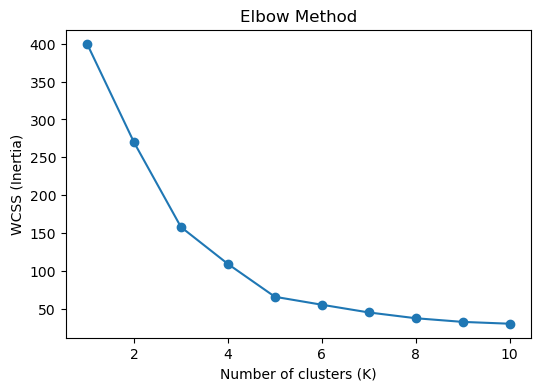

In [6]:
#Elbow Method (choisir K)
wcss = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(list(K_range), wcss, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method")
plt.show()

In [7]:
#Entraîner K-means avec K=5
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

C:\Users\roseb\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [8]:
#Ajouter les clusters au dataset
df["Cluster"] = clusters
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


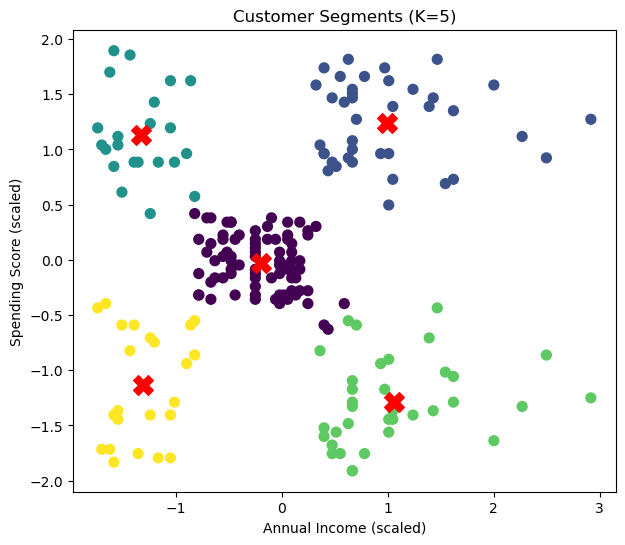

In [9]:
#Visualiser les clusters: tracer les groupes
plt.figure(figsize=(7,6))

plt.scatter(X_scaled[:,0], X_scaled[:,1], 
            c=clusters, cmap='viridis', s=50)

# Centroids
plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            c='red', s=200, marker='X')

plt.title("Customer Segments (K=5)")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.show()

In [10]:
#Comprendre les segments: calcule la moyenne par cluster
df.groupby("Cluster")[["Annual Income (k$)", "Spending Score (1-100)"]].mean()

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


In [11]:
#créer des indicateurs pour dashboard
# Nombre de clients par cluster
df["Cluster"].value_counts()

# Pourcentage par cluster
df["Cluster"].value_counts(normalize=True) * 100

Cluster
0    40.5
1    19.5
3    17.5
4    11.5
2    11.0
Name: proportion, dtype: float64

In [12]:
#ajouter des KPI business
# Revenu moyen global
df["Annual Income (k$)"].mean()

# Spending moyen global
df["Spending Score (1-100)"].mean()

# Cluster le plus rentable (revenu * spending)
df["Value_Score"] = df["Annual Income (k$)"] * df["Spending Score (1-100)"]
df.groupby("Cluster")["Value_Score"].mean().sort_values(ascending=False)

Cluster
1    7101.410256
0    2722.604938
2    2033.227273
3    1547.314286
4     564.608696
Name: Value_Score, dtype: float64

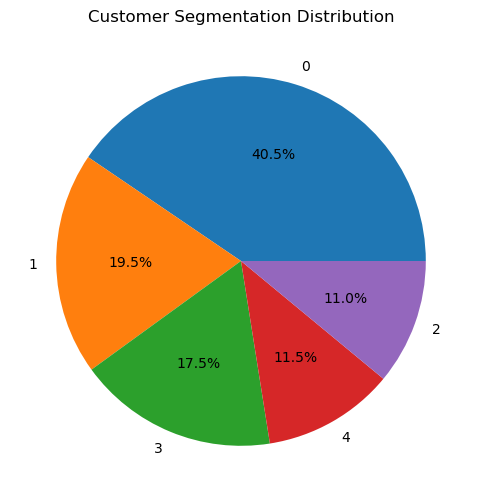

In [13]:
#Pie chart — Répartition des clusters
plt.figure(figsize=(6,6))
df["Cluster"].value_counts().plot.pie(autopct="%1.1f%%")
plt.title("Customer Segmentation Distribution")
plt.ylabel("")
plt.show()

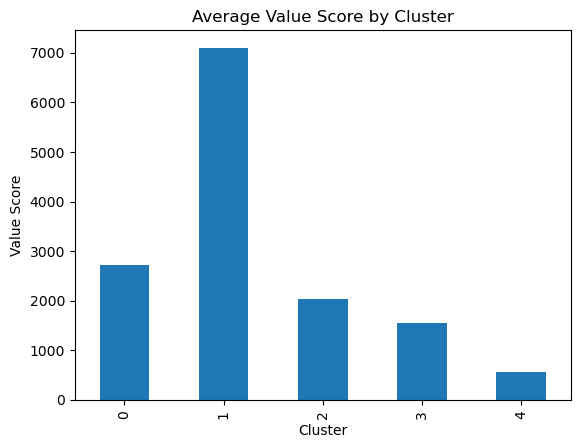

In [14]:
#Bar chart — Valeur moyenne par cluster
df.groupby("Cluster")["Value_Score"].mean().plot(kind="bar")
plt.title("Average Value Score by Cluster")
plt.ylabel("Value Score")
plt.show()

In [15]:
#Export the final dataset: clean file for BI
df_export = df.copy()

df_export.to_csv("Mall_Customers_Segmented.csv", index=False)